In [55]:
import pandas as pd

from pathlib import Path

image_dir = Path("../images")
image_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.shape
df.head()
df.columns.tolist()
df.info()
df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Age                         0
StandardHours               0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
MonthlyIncome               0
dtype: int64

### Step 3A: find constants and understand categories

In [56]:
df.nunique().sort_values()

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


## Step 3B: understand our target

In [57]:
df["Attrition"].value_counts()
df["Attrition"].value_counts(normalize=True).mul(100).round(1)

Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

## Step 3C: inspect the rating scales

In [58]:
rating_cols = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

for col in rating_cols:
    print(f"\n{col}: {sorted(df[col].unique())}")


Education: [1, 2, 3, 4, 5]

EnvironmentSatisfaction: [1, 2, 3, 4]

JobInvolvement: [1, 2, 3, 4]

JobLevel: [1, 2, 3, 4, 5]

JobSatisfaction: [1, 2, 3, 4]

PerformanceRating: [3, 4]

RelationshipSatisfaction: [1, 2, 3, 4]

StockOptionLevel: [0, 1, 2, 3]

WorkLifeBalance: [1, 2, 3, 4]


In [59]:
constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

constant_cols

['EmployeeCount', 'Over18', 'StandardHours']

In [60]:
df["EmployeeNumber"].nunique(), len(df)

(1470, 1470)

## Then create our analysis dataset

In [61]:
df_analysis = df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ]
).copy()



In [62]:
df_analysis["AttritionFlag"] = (
    df_analysis["Attrition"]
    .map({"No": 0, "Yes": 1})
)

In [63]:
df_analysis.shape
df_analysis[["Attrition", "AttritionFlag"]].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


### Step 4: Exploratory Workforce Analysis.

In [64]:
overall_attrition = df_analysis["AttritionFlag"].mean()

print(f"Overall attrition rate: {overall_attrition:.1%}")

Overall attrition rate: 16.1%


In [65]:
def attrition_summary(data, group_col):
    return (
        data.groupby(group_col)
        .agg(
            Employees=("AttritionFlag", "size"),
            Attritions=("AttritionFlag", "sum"),
            AttritionRate=("AttritionFlag", "mean")
        )
        .assign(
            AttritionRate=lambda x: (x["AttritionRate"] * 100).round(1)
        )
        .sort_values("AttritionRate", ascending=False)
    )

In [66]:
attrition_summary(df_analysis, "Department")

,Employees,Attritions,AttritionRate
Department,,,
Sales,446,92,20.6
Human Resources,63,12,19.0
Research & Development,961,133,13.8


In [67]:
attrition_summary(df_analysis, "JobRole")

,Employees,Attritions,AttritionRate
JobRole,,,
Sales Representative,83,33,39.8
Laboratory Technician,259,62,23.9
Human Resources,52,12,23.1
Sales Executive,326,57,17.5
Research Scientist,292,47,16.1
Healthcare Representative,131,9,6.9
Manufacturing Director,145,10,6.9
Manager,102,5,4.9
Research Director,80,2,2.5


In [68]:
attrition_summary(df_analysis, "JobLevel")

,Employees,Attritions,AttritionRate
JobLevel,,,
1,543,143,26.3
3,218,32,14.7
2,534,52,9.7
5,69,5,7.2
4,106,5,4.7


## Step 4B: quantify how far each segment is from the company baseline

In [69]:
def attrition_summary(data, group_col):
    overall_rate = data["AttritionFlag"].mean()

    summary = (
        data.groupby(group_col)
        .agg(
            Employees=("AttritionFlag", "size"),
            Attritions=("AttritionFlag", "sum"),
            AttritionRate=("AttritionFlag", "mean")
        )
    )

    summary["AttritionRatePct"] = (
        summary["AttritionRate"] * 100
    ).round(1)

    summary["AttritionIndex"] = (
        summary["AttritionRate"] / overall_rate
    ).round(2)

    return (
        summary
        .drop(columns="AttritionRate")
        .sort_values("AttritionRatePct", ascending=False)
    )

In [70]:
attrition_summary(df_analysis, "JobRole")

,Employees,Attritions,AttritionRatePct,AttritionIndex
JobRole,,,,
Sales Representative,83,33,39.8,2.47
Laboratory Technician,259,62,23.9,1.48
Human Resources,52,12,23.1,1.43
Sales Executive,326,57,17.5,1.08
Research Scientist,292,47,16.1,1.00
Healthcare Representative,131,9,6.9,0.43
Manufacturing Director,145,10,6.9,0.43
Manager,102,5,4.9,0.30
Research Director,80,2,2.5,0.16


## Step 4C: make our first portfolio-quality chart

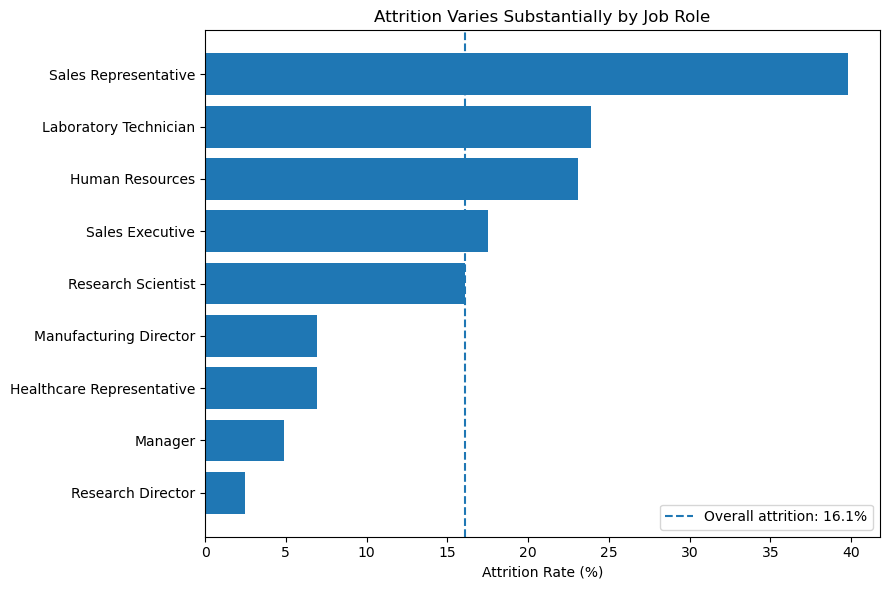

In [71]:
job_role = attrition_summary(
    df_analysis,
    "JobRole"
).sort_values("AttritionRatePct")

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    job_role.index,
    job_role["AttritionRatePct"]
)

ax.axvline(
    overall_attrition * 100,
    linestyle="--",
    label=f"Overall attrition: {overall_attrition:.1%}"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_title("Attrition Varies Substantially by Job Role")
ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "attrition-by-job-role.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 5A: Work-context and experience factors

In [72]:
factors = [
    "OverTime",
    "BusinessTravel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance"
]

for factor in factors:
    print(f"\n--- {factor} ---")
    display(attrition_summary(df_analysis, factor))


--- OverTime ---


,Employees,Attritions,AttritionRatePct,AttritionIndex
OverTime,,,,
Yes,416,127,30.5,1.89
No,1054,110,10.4,0.65



--- BusinessTravel ---


,Employees,Attritions,AttritionRatePct,AttritionIndex
BusinessTravel,,,,
Travel_Frequently,277,69,24.9,1.55
Travel_Rarely,1043,156,15.0,0.93
Non-Travel,150,12,8.0,0.50



--- JobSatisfaction ---


...

,Employees,Attritions,AttritionRatePct,AttritionIndex
EnvironmentSatisfaction,,,,
1,284,72,25.4,1.57
2,287,43,15.0,0.93
3,453,62,13.7,0.85
4,446,60,13.5,0.83



--- JobInvolvement ---


,Employees,Attritions,AttritionRatePct,AttritionIndex
JobInvolvement,,,,
1,83,28,33.7,2.09
2,375,71,18.9,1.17
3,868,125,14.4,0.89
4,144,13,9.0,0.56



--- WorkLifeBalance ---


,Employees,Attritions,AttritionRatePct,AttritionIndex
WorkLifeBalance,,,,
1,80,25,31.2,1.94
4,153,27,17.6,1.09
2,344,58,16.9,1.05
3,893,127,14.2,0.88


## Step 5B: Compare key numeric variables

In [73]:
numeric_factors = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

comparison = (
    df_analysis
    .groupby("Attrition")[numeric_factors]
    .mean()
    .T
    .round(1)
)

comparison

Attrition,No,Yes
Age,37.6,33.6
MonthlyIncome,6832.7,4787.1
DistanceFromHome,8.9,10.6
TotalWorkingYears,11.9,8.2
YearsAtCompany,7.4,5.1
YearsInCurrentRole,4.5,2.9
YearsSinceLastPromotion,2.2,1.9
YearsWithCurrManager,4.4,2.9


## Step 5C: add the difference


In [74]:
comparison["Difference_Yes_minus_No"] = (
    comparison["Yes"] - comparison["No"]
).round(1)

comparison

Attrition,No,Yes,Difference_Yes_minus_No
Age,37.6,33.6,-4.0
MonthlyIncome,6832.7,4787.1,-2045.6
DistanceFromHome,8.9,10.6,1.7
TotalWorkingYears,11.9,8.2,-3.7
YearsAtCompany,7.4,5.1,-2.3
YearsInCurrentRole,4.5,2.9,-1.6
YearsSinceLastPromotion,2.2,1.9,-0.3
YearsWithCurrManager,4.4,2.9,-1.5


## Step 5D: median check

In [75]:
median_comparison = (
    df_analysis
    .groupby("Attrition")[numeric_factors]
    .median()
    .T
    .round(1)
)

median_comparison

Attrition,No,Yes
Age,36.0,32.0
MonthlyIncome,5204.0,3202.0
DistanceFromHome,7.0,9.0
TotalWorkingYears,10.0,7.0
YearsAtCompany,6.0,3.0
YearsInCurrentRole,3.0,2.0
YearsSinceLastPromotion,1.0,1.0
YearsWithCurrManager,3.0,2.0


## Step 6: Validate the signals statistically

In [76]:
import pandas as pd

overtime_table = pd.crosstab(
    df_analysis["OverTime"],
    df_analysis["Attrition"]
)

overtime_table

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [77]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(overtime_table)

print(f"Chi-square: {chi2:.2f}")
print(f"P-value: {p:.6f}")

Chi-square: 87.56
P-value: 0.000000


In [78]:
a = overtime_table.loc["Yes", "Yes"]
b = overtime_table.loc["Yes", "No"]
c = overtime_table.loc["No", "Yes"]
d = overtime_table.loc["No", "No"]

odds_ratio = (a / b) / (c / d)

print(f"Overtime odds ratio: {odds_ratio:.2f}")

Overtime odds ratio: 3.77


In [79]:
from scipy.stats import chi2_contingency

categorical_factors = [
    "BusinessTravel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "WorkLifeBalance",
    "JobRole",
    "JobLevel"
]

results = []

for factor in categorical_factors:
    table = pd.crosstab(
        df_analysis[factor],
        df_analysis["Attrition"]
    )

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Factor": factor,
        "ChiSquare": round(chi2, 2),
        "p_value": p
    })

pd.DataFrame(results).sort_values("p_value")

,Factor,ChiSquare,p_value
5,JobRole,86.19,2.752482e-15
6,JobLevel,72.53,6.634685e-15
3,JobInvolvement,28.49,2.863181e-06
0,BusinessTravel,24.18,5.608614e-06
2,EnvironmentSatisfaction,22.50,5.123469e-05
1,JobSatisfaction,17.51,5.563005e-04
4,WorkLifeBalance,16.33,9.725699e-04


In [80]:
import numpy as np

numeric_factors = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

effect_results = []

for var in numeric_factors:
    stay = df_analysis.loc[
        df_analysis["Attrition"] == "No", var
    ]

    leave = df_analysis.loc[
        df_analysis["Attrition"] == "Yes", var
    ]

    pooled_sd = np.sqrt(
        (
            (len(stay)-1) * stay.std()**2 +
            (len(leave)-1) * leave.std()**2
        )
        /
        (len(stay) + len(leave) - 2)
    )

    cohens_d = (
        leave.mean() - stay.mean()
    ) / pooled_sd

    effect_results.append({
        "Variable": var,
        "StayMean": round(stay.mean(), 1),
        "LeaveMean": round(leave.mean(), 1),
        "CohensD": round(cohens_d, 2)
    })

pd.DataFrame(effect_results).sort_values(
    "CohensD",
    key=abs,
    ascending=False
)

,Variable,StayMean,LeaveMean,CohensD
3,TotalWorkingYears,11.9,8.2,-0.47
0,Age,37.6,33.6,-0.44
1,MonthlyIncome,6832.7,4787.1,-0.44
5,YearsInCurrentRole,4.5,2.9,-0.44
7,YearsWithCurrManager,4.4,2.9,-0.43
4,YearsAtCompany,7.4,5.1,-0.37
2,DistanceFromHome,8.9,10.6,0.21
6,YearsSinceLastPromotion,2.2,1.9,-0.09


## Step 7: Multivariate logistic regression

Which factors remain associated with attrition after accounting for other relevant workforce characteristics?

7A. First check correlations among the overlapping numeric variables

In [81]:
correlation_vars = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
    "DistanceFromHome"
]

df_analysis[correlation_vars].corr().round(2)

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,DistanceFromHome
Age,1.00,0.50,0.68,0.31,0.21,0.20,-0.00
MonthlyIncome,0.50,1.00,0.77,0.51,0.36,0.34,-0.02
TotalWorkingYears,0.68,0.77,1.00,0.63,0.46,0.46,0.00
YearsAtCompany,0.31,0.51,0.63,1.00,0.76,0.77,0.01
YearsInCurrentRole,0.21,0.36,0.46,0.76,1.00,0.71,0.02
YearsWithCurrManager,0.20,0.34,0.46,0.77,0.71,1.00,0.01
DistanceFromHome,-0.00,-0.02,0.00,0.01,0.02,0.01,1.00


7B. Fit the logistic regression

In [82]:
import statsmodels.formula.api as smf

formula = """
AttritionFlag ~
C(OverTime, Treatment(reference="No")) +
C(BusinessTravel, Treatment(reference="Non-Travel")) +
C(JobLevel, Treatment(reference=1)) +
C(JobInvolvement, Treatment(reference=1)) +
C(EnvironmentSatisfaction, Treatment(reference=1)) +
C(JobSatisfaction, Treatment(reference=1)) +
C(WorkLifeBalance, Treatment(reference=1)) +
Age +
DistanceFromHome +
YearsAtCompany
"""

model = smf.logit(
    formula=formula,
    data=df_analysis
).fit()

model.summary()

Optimization terminated successfully.
         Current function value: 0.336837
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          AttritionFlag   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1447
Method:                           MLE   Df Model:                           22
Date:                Sat, 03 Oct 2026   Pseudo R-squ.:                  0.2374
Time:                        14:01:05   Log-Likelihood:                -495.15
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 2.544e-52
=============================================================================================================================================
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                     1.9916      0.657      3.032      0.002       0.704       3.279
C(OverTime, Treatment(reference="No"))[T.Yes]                                 1.6670      0.171      9.728      0.000       1.331       2.003
C(BusinessTravel, Treatment(reference="Non-Travel"))[T.Travel_Frequently]     1.6691      0.382      4.367      0.000       0.920       2.418
C(BusinessTravel, Treatment(reference="Non-Travel"))[T.Travel_Rarely]         0.8808      0.357      2.466      0.014       0.181       1.581
C(JobLevel, Treatment(reference=1))[T.2]                                     -1.1432      0.205     -5.572      0.000      -1.545      -0.741
C(JobLevel, Treatment(reference=1))[T.3]                                     -0.4925      0.268     -1.838      0.066      -1.018       0.033
C(JobLevel, Treatment(reference=1))[T.4]                                     -1.3521      0.541     -2.499      0.012      -2.413      -0.292
C(JobLevel, Treatment(reference=1))[T.5]                                     -0.6317      0.568     -1.112      0.266      -1.745       0.482
C(JobInvolvement, Treatment(reference=1))[T.2]                               -1.0390      0.323     -3.221      0.001      -1.671      -0.407
C(JobInvolvement, Treatment(reference=1))[T.3]                               -1.4112      0.304     -4.637      0.000      -2.008      -0.815
C(JobInvolvement, Treatment(reference=1))[T.4]                               -2.0680      0.425     -4.862      0.000      -2.902      -1.234
C(EnvironmentSatisfaction, Treatment(reference=1))[T.2]                      -0.9071      0.252     -3.593      0.000      -1.402      -0.412
C(EnvironmentSatisfaction, Treatment(reference=1))[T.3]                      -0.9854      0.225     -4.387      0.000      -1.426      -0.545
C(EnvironmentSatisfaction, Treatment(reference=1))[T.4]                      -1.1312      0.229     -4.940      0.000      -1.580      -0.682
C(JobSatisfaction, Treatment(reference=1))[T.2]                              -0.4431      0.248     -1.790      0.074      -0.928       0.042
C(JobSatisfaction, Treatment(reference=1))[T.3]                              -0.5122      0.218     -2.349      0.019      -0.940      -0.085
C(JobSatisfaction, Treatment(reference=1))[T.4]                              -1.1499      0.236     -4.866      0.000      -1.613      -0.687
C(WorkLifeBalance, Treatment(reference=1))[T.2]                              -0.9806      0.329     -2.984      0.003      -1.625      -0.336
C(WorkLifeBalance, Treatment(reference=1))[T.3]                              -1.2014      0.305     -3.945      0.000      -1.798      -0.604
C(WorkLifeBalance, Treatment(reference=1))[T.4]                              -0.7875      0.374     -2.104      0.035

7C. Convert the coefficients into odds ratios

In [83]:
import numpy as np
import pandas as pd

conf = model.conf_int()

odds_ratios = pd.DataFrame({
    "OddsRatio": np.exp(model.params),
    "CI_Lower": np.exp(conf[0]),
    "CI_Upper": np.exp(conf[1]),
    "p_value": model.pvalues
})

odds_ratios.round(3)

,OddsRatio,CI_Lower,CI_Upper,p_value
Intercept,7.327,2.022,26.549,0.002
"C(OverTime, Treatment(reference=""No""))[T.Yes]",5.296,3.786,7.410,0.000
"C(BusinessTravel, Treatment(reference=""Non-Travel""))[T.Travel_Frequently]",5.307,2.509,11.225,0.000
"C(BusinessTravel, Treatment(reference=""Non-Travel""))[T.Travel_Rarely]",2.413,1.198,4.859,0.014
"C(JobLevel, Treatment(reference=1))[T.2]",0.319,0.213,0.477,0.000
"C(JobLevel, Treatment(reference=1))[T.3]",0.611,0.361,1.033,0.066
"C(JobLevel, Treatment(reference=1))[T.4]",0.259,0.090,0.747,0.012
"C(JobLevel, Treatment(reference=1))[T.5]",0.532,0.175,1.619,0.266
"C(JobInvolvement, Treatment(reference=1))[T.2]",0.354,0.188,0.666,0.001
"C(JobInvolvement, Treatment(reference=1))[T.3]",0.244,0.134,0.443,0.000


Step 8: Model quality before we turn this into recommendations

In [84]:
print(f"McFadden Pseudo R²: {model.prsquared:.3f}")
print(f"Log-Likelihood: {model.llf:.2f}")
print(f"LLR p-value: {model.llr_pvalue:.6f}")

McFadden Pseudo R²: 0.237
Log-Likelihood: -495.15
LLR p-value: 0.000000


In [85]:
from sklearn.metrics import roc_auc_score

predicted_prob = model.predict(df_analysis)

auc = roc_auc_score(
    df_analysis["AttritionFlag"],
    predicted_prob
)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.820


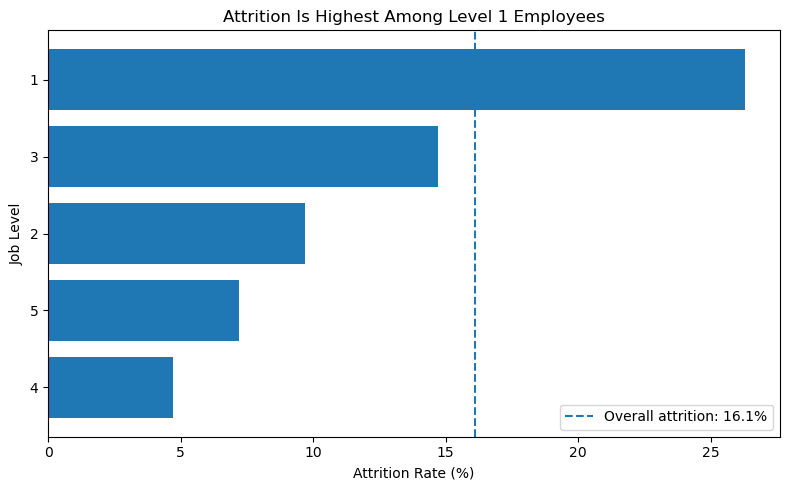

In [86]:
job_level = attrition_summary(
    df_analysis,
    "JobLevel"
).sort_values("AttritionRatePct")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    job_level.index.astype(str),
    job_level["AttritionRatePct"]
)

ax.axvline(
    overall_attrition * 100,
    linestyle="--",
    label=f"Overall attrition: {overall_attrition:.1%}"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("Job Level")
ax.set_title("Attrition Is Highest Among Level 1 Employees")
ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "attrition-by-job-level.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 10B: What Is Associated With Attrition

Visual 1: Overtime

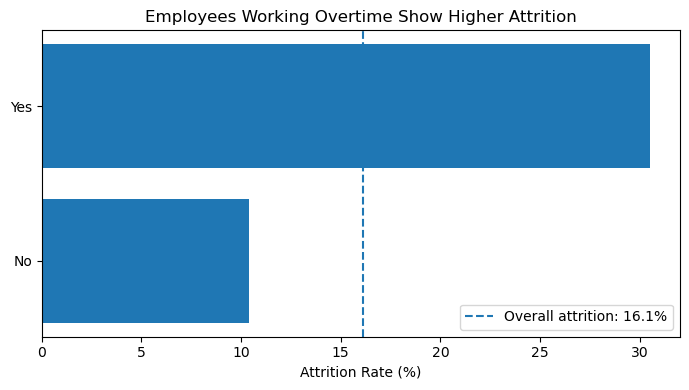

In [87]:
overtime = attrition_summary(
    df_analysis,
    "OverTime"
).sort_values("AttritionRatePct")

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    overtime.index,
    overtime["AttritionRatePct"]
)

ax.axvline(
    overall_attrition * 100,
    linestyle="--",
    label=f"Overall attrition: {overall_attrition:.1%}"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_title("Employees Working Overtime Show Higher Attrition")
ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "attrition-by-overtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Visual 2: Business Travel

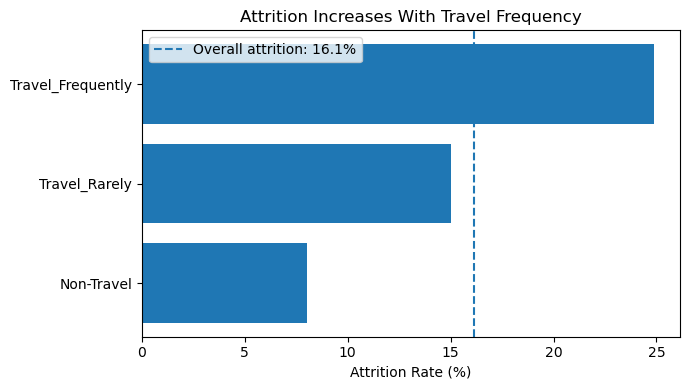

In [88]:
travel = attrition_summary(
    df_analysis,
    "BusinessTravel"
).sort_values("AttritionRatePct")

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    travel.index,
    travel["AttritionRatePct"]
)

ax.axvline(
    overall_attrition * 100,
    linestyle="--",
    label=f"Overall attrition: {overall_attrition:.1%}"
)

ax.set_xlabel("Attrition Rate (%)")
ax.set_ylabel("")
ax.set_title("Attrition Increases With Travel Frequency")
ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "attrition-by-business-travel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Visual 3: Job Involvement

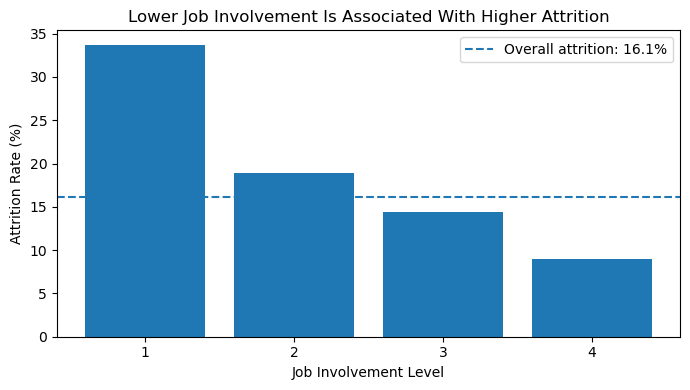

In [89]:
involvement = attrition_summary(
    df_analysis,
    "JobInvolvement"
).sort_index()

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    involvement.index.astype(str),
    involvement["AttritionRatePct"]
)

ax.axhline(
    overall_attrition * 100,
    linestyle="--",
    label=f"Overall attrition: {overall_attrition:.1%}"
)

ax.set_xlabel("Job Involvement Level")
ax.set_ylabel("Attrition Rate (%)")
ax.set_title("Lower Job Involvement Is Associated With Higher Attrition")
ax.legend()

plt.tight_layout()

plt.savefig(
    image_dir / "attrition-by-job-involvement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Step 10C: Adjusted Analysis

1. Create a selected odds-ratio chart

In [90]:
selected_predictors = {
    'C(OverTime, Treatment(reference="No"))[T.Yes]':
        'Overtime: Yes vs No',

    'C(BusinessTravel, Treatment(reference="Non-Travel"))[T.Travel_Frequently]':
        'Frequent Travel vs No Travel',

    'C(BusinessTravel, Treatment(reference="Non-Travel"))[T.Travel_Rarely]':
        'Rare Travel vs No Travel',

    'C(JobInvolvement, Treatment(reference=1))[T.4]':
        'Job Involvement: 4 vs 1',

    'C(EnvironmentSatisfaction, Treatment(reference=1))[T.4]':
        'Environment Satisfaction: 4 vs 1',

    'C(JobSatisfaction, Treatment(reference=1))[T.4]':
        'Job Satisfaction: 4 vs 1',

    'C(WorkLifeBalance, Treatment(reference=1))[T.3]':
        'Work-Life Balance: 3 vs 1',

    'Age':
        'Age (per year)',

    'DistanceFromHome':
        'Distance From Home (per unit)'
}

adjusted_plot = (
    odds_ratios
    .loc[list(selected_predictors.keys())]
    .copy()
)

adjusted_plot["Label"] = [
    selected_predictors[i]
    for i in adjusted_plot.index
]

adjusted_plot[
    ["Label", "OddsRatio", "CI_Lower", "CI_Upper", "p_value"]
].round(3)

,Label,OddsRatio,CI_Lower,CI_Upper,p_value
"C(OverTime, Treatment(reference=""No""))[T.Yes]",Overtime: Yes vs No,5.296,3.786,7.410,0.000
"C(BusinessTravel, Treatment(reference=""Non-Travel""))[T.Travel_Frequently]",Frequent Travel vs No Travel,5.307,2.509,11.225,0.000
"C(BusinessTravel, Treatment(reference=""Non-Travel""))[T.Travel_Rarely]",Rare Travel vs No Travel,2.413,1.198,4.859,0.014
"C(JobInvolvement, Treatment(reference=1))[T.4]",Job Involvement: 4 vs 1,0.126,0.055,0.291,0.000
"C(EnvironmentSatisfaction, Treatment(reference=1))[T.4]",Environment Satisfaction: 4 vs 1,0.323,0.206,0.505,0.000
"C(JobSatisfaction, Treatment(reference=1))[T.4]",Job Satisfaction: 4 vs 1,0.317,0.199,0.503,0.000
"C(WorkLifeBalance, Treatment(reference=1))[T.3]",Work-Life Balance: 3 vs 1,0.301,0.166,0.546,0.000
Age,Age (per year),0.964,0.944,0.985,0.001
DistanceFromHome,Distance From Home (per unit),1.038,1.018,1.058,0.000


2. Create a forest plot

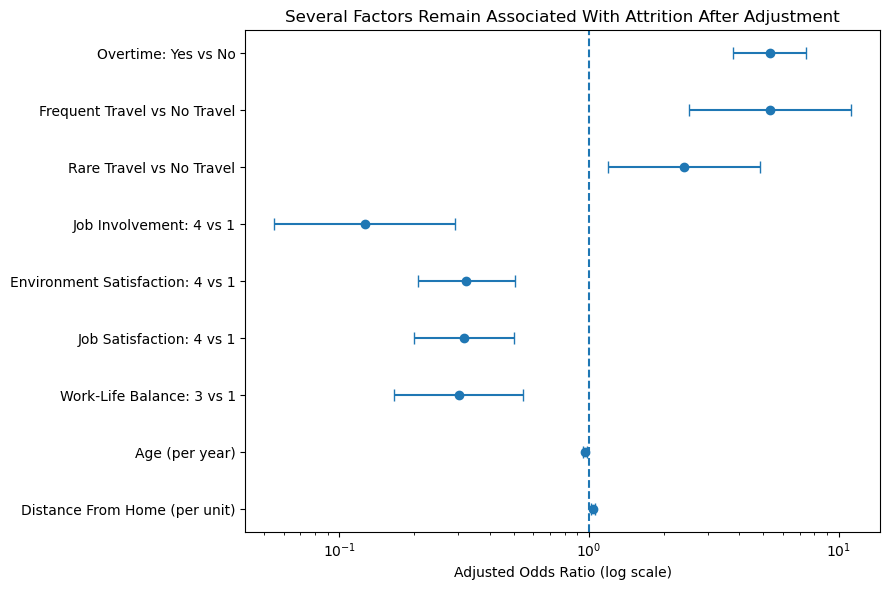

In [91]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = adjusted_plot.iloc[::-1]

xerr = [
    plot_data["OddsRatio"] - plot_data["CI_Lower"],
    plot_data["CI_Upper"] - plot_data["OddsRatio"]
]

ax.errorbar(
    plot_data["OddsRatio"],
    plot_data["Label"],
    xerr=xerr,
    fmt="o",
    capsize=4
)

ax.axvline(
    1,
    linestyle="--"
)

ax.set_xscale("log")
ax.set_xlabel("Adjusted Odds Ratio (log scale)")
ax.set_ylabel("")
ax.set_title("Several Factors Remain Associated With Attrition After Adjustment")

plt.tight_layout()

plt.savefig(
    image_dir / "adjusted-odds-ratios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()